In [1]:
## TOC

In [2]:
import numpy as np
from sklearn.cluster import KMeans

# Function to convert 'MM:SS' format to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Sample data
group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array(["26:16", "33:32", "28:01", "30:36", "20:39", "11:49", 
                          "28:57", "35:36", "25:11", "28:25", "28:50", "21:05", 
                          "30:50", "21:55", "20:46", "16:13", "12:28", "19:15", "31:17"])
at_total_time = np.array(["18:01", "24:38", "17:42", "22:40", "30:09", "20:05", 
                          "18:41", "24:00", "14:14", "23:11", "20:00", "11:49", 
                          "22:41", "22:02", "7:09", "17:14", "17:12", "26:59", "14:43"])

# Convert VR and AT total time to seconds
vr_total_seconds = np.array([time_to_seconds(time) for time in vr_total_time])
at_total_seconds = np.array([time_to_seconds(time) for time in at_total_time])

# Stack the VR and AT times for clustering
X = np.column_stack((vr_total_seconds, at_total_seconds))

# Apply KMeans clustering to form 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# Compare clusters with original group assignment
print("Clusters:", clusters)
print("Group Assignments:", group)


Clusters: [0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0]
Group Assignments: [1 2 2 2 1 2 2 1 1 1 2 1 1 2 1 2 1 2 2]


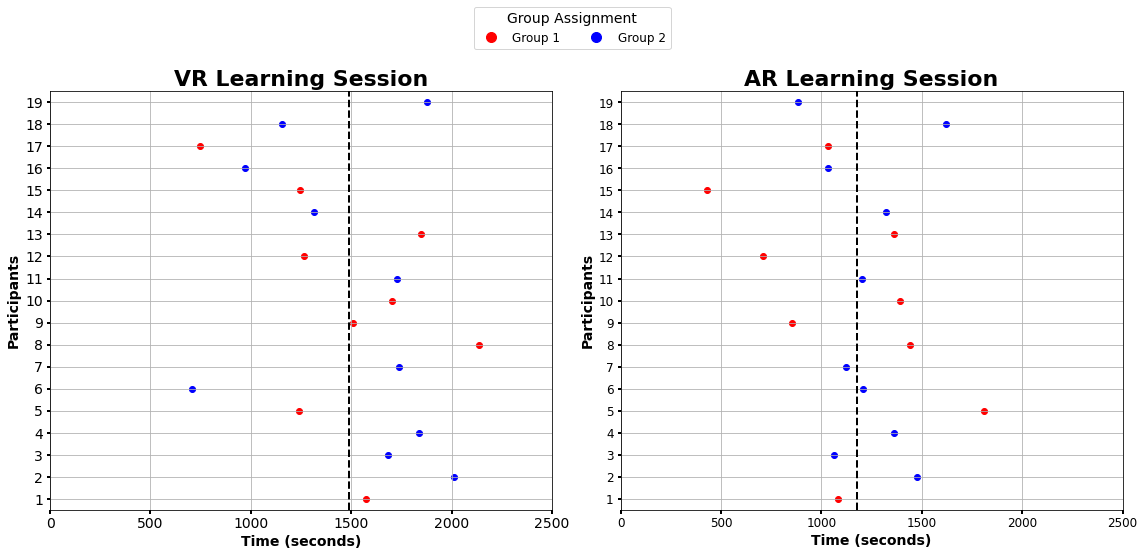

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Function to convert 'MM:SS' format to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Data
group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array(["26:16", "33:32", "28:01", "30:36", "20:39", "11:49", 
                          "28:57", "35:36", "25:11", "28:25", "28:50", "21:05", 
                          "30:50", "21:55", "20:46", "16:13", "12:28", "19:15", "31:17"])
ar_total_time = np.array(["18:01", "24:38", "17:42", "22:40", "30:09", "20:05", 
                          "18:41", "24:00", "14:14", "23:11", "20:00", "11:49", 
                          "22:41", "22:02", "7:09", "17:14", "17:12", "26:59", "14:43"])

# Convert VR and AR total time to seconds
vr_total_seconds = np.array([time_to_seconds(time) for time in vr_total_time])
ar_total_seconds = np.array([time_to_seconds(time) for time in ar_total_time])

# Calculate mean times
vr_mean_time = np.mean(vr_total_seconds)
ar_mean_time = np.mean(ar_total_seconds)

# Plotting two subplots: VR and AR times
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  # Increased figure size

# Set the same limits for both plots with added padding
x_min, x_max = 0, 2500  # Fixed x-axis range
y_min, y_max = 0.5, 19.5  # Y-axis padding for participant range

# Plot VR times
for i in range(len(vr_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'  # Color based on group
    ax[0].scatter(vr_total_seconds[i], i + 1, color=color, marker='o')  # Use only circles

# Add vertical dashed line for mean VR time
ax[0].axvline(vr_mean_time, color='black', linestyle='--', linewidth=2, label=f'Mean: {vr_mean_time:.1f} sec')

# Customizing VR subplot
ax[0].set_title('VR Learning Session', fontweight='bold', fontsize=22)
ax[0].set_xlabel('Time (seconds)', fontweight='bold', fontsize=14)
ax[0].set_ylabel('Participants', fontweight='bold', fontsize=14)
ax[0].tick_params(axis='x', labelsize=14, width=2)
ax[0].tick_params(axis='y', labelsize=14, width=2)
ax[0].set_xlim(x_min, x_max)
ax[0].set_ylim(y_min, y_max)
ax[0].set_yticks(np.arange(1, 20, 1))  # Show y-axis ticks from 1 to 19
ax[0].set_xticks(np.arange(0, 2501, 500))  # Set x-axis ticks from 0 to 2500 with a step of 500
ax[0].grid(True)

# Plot AR times
for i in range(len(ar_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'  # Color based on group
    ax[1].scatter(ar_total_seconds[i], i + 1, color=color, marker='o')  # Use only circles

# Add vertical dashed line for mean AR time
ax[1].axvline(ar_mean_time, color='black', linestyle='--', linewidth=2, label=f'Mean: {ar_mean_time:.1f} sec')

# Customizing AR subplot
ax[1].set_title('AR Learning Session', fontweight='bold', fontsize=22)
ax[1].set_xlabel('Time (seconds)', fontweight='bold', fontsize=14)
ax[1].set_ylabel('Participants', fontweight='bold', fontsize=14)
ax[1].tick_params(axis='x', labelsize=12, width=2)
ax[1].tick_params(axis='y', labelsize=12, width=2)
ax[1].set_xlim(x_min, x_max)
ax[1].set_ylim(y_min, y_max)
ax[1].set_yticks(np.arange(1, 20, 1))  # Show y-axis ticks from 1 to 19
ax[1].set_xticks(np.arange(0, 2501, 500))  # Set x-axis ticks from 0 to 2500 with a step of 500
ax[1].grid(True)

# Define custom legend elements (only circles for Group 1 and Group 2)
red_circle = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Group 1')
blue_circle = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='Group 2')

# Adding the correct legend to the top, higher above the plot
fig.legend(handles=[red_circle, blue_circle], loc='upper center', ncol=2, fontsize=12, title='Group Assignment', title_fontsize='14', bbox_to_anchor=(0.5, 1))

# Ensuring a tight layout
plt.tight_layout(rect=[0, 0.03, 1, 0.90])  # Adjusting layout to make space for the legend
file_name = 'Updated_Time_Cluster.png'
plt.savefig(file_name)
plt.show()


In [4]:
# Original code (including imports, data, and plotting functions)

# Existing code...

# Print original group assignment and adjusted cluster assignment
print("Participant | Group Assignment | Adjusted VR Cluster | Adjusted AR Cluster")
print("--------------------------------------------------------------------------")
for i in range(len(group)):
    adjusted_vr_cluster = 1 if vr_clusters[i] == 0 else 2
    adjusted_ar_cluster = 1 if ar_clusters[i] == 0 else 2
    print(f"{i + 1:<11} | {group[i]:<15} | {adjusted_vr_cluster:<19} | {adjusted_ar_cluster}")


Participant | Group Assignment | Adjusted VR Cluster | Adjusted AR Cluster
--------------------------------------------------------------------------
1           | 1               | 1                   | 2
2           | 2               | 1                   | 1
3           | 2               | 1                   | 2
4           | 2               | 1                   | 2
5           | 1               | 2                   | 1
6           | 2               | 2                   | 2
7           | 2               | 1                   | 2
8           | 1               | 1                   | 1
9           | 1               | 1                   | 2
10          | 1               | 1                   | 2
11          | 2               | 1                   | 2
12          | 1               | 2                   | 2
13          | 1               | 1                   | 2
14          | 2               | 2                   | 2
15          | 1               | 2                   | 2
16        

In [5]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import matplotlib.lines as mlines

# Function to convert 'MM:SS' format to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Data
group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array(["26:16", "33:32", "28:01", "30:36", "20:39", "11:49", 
                          "28:57", "35:36", "25:11", "28:25", "28:50", "21:05", 
                          "30:50", "21:55", "20:46", "16:13", "12:28", "19:15", "31:17"])
ar_total_time = np.array(["18:01", "24:38", "17:42", "22:40", "30:09", "20:05", 
                          "18:41", "24:00", "14:14", "23:11", "20:00", "11:49", 
                          "22:41", "22:02", "7:09", "17:14", "17:12", "26:59", "14:43"])

# Convert VR and AR total time to seconds
vr_total_seconds = np.array([time_to_seconds(time) for time in vr_total_time])
ar_total_seconds = np.array([time_to_seconds(time) for time in ar_total_time])

# Combine VR and AR times into one array (for clustering)
all_times = np.concatenate((vr_total_seconds, ar_total_seconds)).reshape(-1, 1)

# Apply KMeans clustering to split participants into two clusters (lesser and more time)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(all_times)

# Ensure Cluster 1 represents lower times and Cluster 2 represents higher times
cluster_0_mean = np.mean(all_times[clusters == 0])
cluster_1_mean = np.mean(all_times[clusters == 1])

# Adjust clusters to make cluster 1 the lower time and cluster 2 the higher time
if cluster_0_mean < cluster_1_mean:
    adjusted_clusters = np.where(clusters == 0, 1, 2)
else:
    adjusted_clusters = np.where(clusters == 1, 1, 2)

# Separate VR and AR adjusted cluster assignments
vr_clusters = adjusted_clusters[:len(vr_total_seconds)]
ar_clusters = adjusted_clusters[len(vr_total_seconds):]

# Create a DataFrame to display original group and final cluster assignments
participants = np.arange(1, len(group) + 1)
df = pd.DataFrame({
    'Participant': participants,
    'Original Group': group,
    'VR Cluster': vr_clusters,
    'AR Cluster': ar_clusters
})

# Print the table
print(df)


    Participant  Original Group  VR Cluster  AR Cluster
0             1               1           2           1
1             2               2           2           2
2             3               2           2           1
3             4               2           2           1
4             5               1           1           2
5             6               2           1           1
6             7               2           2           1
7             8               1           2           2
8             9               1           2           1
9            10               1           2           1
10           11               2           2           1
11           12               1           1           1
12           13               1           2           1
13           14               2           1           1
14           15               1           1           1
15           16               2           1           1
16           17               1           1     

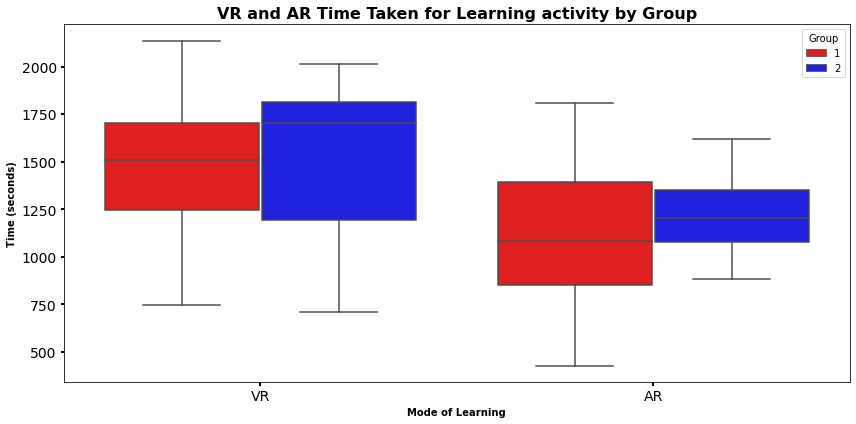

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Create a dataframe for easier plotting with seaborn
# Concatenate VR and AR data in a long format, using 38 rows in total (19 for VR, 19 for AR)
data = {
    'Group': np.concatenate((group, group)),  # Concatenate Group 1 and Group 2 values for both VR and AR
    'Time': np.concatenate((vr_total_seconds, ar_total_seconds)),  # Concatenate VR and AR times
    'Mode': ['VR'] * len(vr_total_seconds) + ['AR'] * len(ar_total_seconds)  # Add labels for VR and AR
}

df = pd.DataFrame(data)

# Create the figure for boxplots
plt.figure(figsize=(12, 6))

# Boxplot for VR and AR times together
sns.boxplot(x='Mode', y='Time', hue='Group', data=df, palette=['red', 'blue'])
plt.title('VR and AR Time Taken for Learning activity by Group', fontweight='bold', fontsize=16)
plt.xlabel('Mode of Learning', fontweight='bold')
plt.ylabel('Time (seconds)', fontweight='bold')
plt.tick_params(axis='x', labelsize=14, width=2)  # X-axis tick size and width
plt.tick_params(axis='y', labelsize=14, width=2)

# Adjust layout and show the plot
plt.tight_layout()
file_name = 'Time_Box_Plot.png'
plt.savefig(file_name)
plt.show()


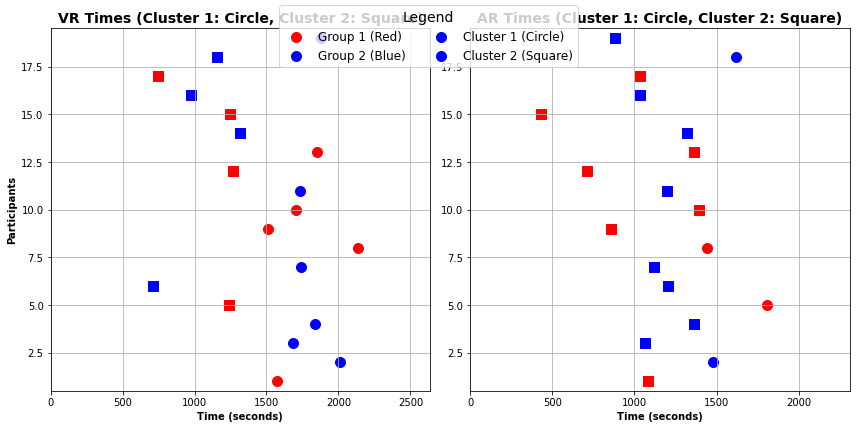

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Function to convert 'MM:SS' format to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Data
group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array(["26:16", "33:32", "28:01", "30:36", "20:39", "11:49", 
                          "28:57", "35:36", "25:11", "28:25", "28:50", "21:05", 
                          "30:50", "21:55", "20:46", "16:13", "12:28", "19:15", "31:17"])
ar_total_time = np.array(["18:01", "24:38", "17:42", "22:40", "30:09", "20:05", 
                          "18:41", "24:00", "14:14", "23:11", "20:00", "11:49", 
                          "22:41", "22:02", "7:09", "17:14", "17:12", "26:59", "14:43"])

# Convert VR and AR total time to seconds
vr_total_seconds = np.array([time_to_seconds(time) for time in vr_total_time])
ar_total_seconds = np.array([time_to_seconds(time) for time in ar_total_time])

# Combine VR and AR times into one array (for clustering)
all_times = np.concatenate((vr_total_seconds, ar_total_seconds)).reshape(-1, 1)

# Apply KMeans clustering to split participants into two clusters (lesser and more time)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(all_times)

# Separate VR and AR cluster assignments
vr_clusters = clusters[:len(vr_total_seconds)]
ar_clusters = clusters[len(vr_total_seconds):]

# Create figure for two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# VR Times Scatter Plot
for i in range(len(vr_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'  # Color based on group
    marker = 'o' if vr_clusters[i] == 0 else 's'  # Marker based on cluster
    ax[0].scatter(vr_total_seconds[i], i + 1, color=color, marker=marker, s=100)  # Scatter plot for each participant

ax[0].set_title('VR Times (Cluster 1: Circle, Cluster 2: Square)', fontweight='bold', fontsize=14)
ax[0].set_xlabel('Time (seconds)', fontweight='bold')
ax[0].set_ylabel('Participants', fontweight='bold')
ax[0].set_xlim(0, max(vr_total_seconds) + 500)
ax[0].set_ylim(0.5, 19.5)
ax[0].grid(True)

# AR Times Scatter Plot
for i in range(len(ar_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'  # Color based on group
    marker = 'o' if ar_clusters[i] == 0 else 's'  # Marker based on cluster
    ax[1].scatter(ar_total_seconds[i], i + 1, color=color, marker=marker, s=100)  # Scatter plot for each participant

ax[1].set_title('AR Times (Cluster 1: Circle, Cluster 2: Square)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Time (seconds)', fontweight='bold')
ax[1].set_xlim(0, max(ar_total_seconds) + 500)
ax[1].set_ylim(0.5, 19.5)
ax[1].grid(True)

# Adding a legend to describe colors and markers
fig.legend(['Group 1 (Red)', 'Group 2 (Blue)', 'Cluster 1 (Circle)', 'Cluster 2 (Square)'], 
           loc='upper center', ncol=2, fontsize=12, title='Legend', title_fontsize='14')

# Final layout adjustment and showing the plot
plt.tight_layout()
plt.show()


In [8]:
data = {
    'Participant': np.arange(1, len(group) + 1),
    'Group': group,
    'VR Cluster': vr_clusters,  # Cluster numbers 1 and 2
    'AR Cluster': ar_clusters   # Cluster numbers 1 and 2
}

df_clusters = pd.DataFrame(data)

# Print the DataFrame showing participants' original group and their cluster assignments
print("\nParticipant Group and Cluster Assignments:")
print(df_clusters)




Participant Group and Cluster Assignments:
    Participant  Group  VR Cluster  AR Cluster
0             1      1           0           1
1             2      2           0           0
2             3      2           0           1
3             4      2           0           1
4             5      1           1           0
5             6      2           1           1
6             7      2           0           1
7             8      1           0           0
8             9      1           0           1
9            10      1           0           1
10           11      2           0           1
11           12      1           1           1
12           13      1           0           1
13           14      2           1           1
14           15      1           1           1
15           16      2           1           1
16           17      1           1           1
17           18      2           1           0
18           19      2           0           1


In [9]:
# Calculate counts for Group 1 (VR first) and Group 2 (AR first)

# Group 1 (VR First)
group1_vr_cluster_1 = np.sum((group == 1) & (vr_clusters == 0))  # VR Cluster 1
group1_ar_cluster_2 = np.sum((group == 1) & (ar_clusters == 1))  # AR Cluster 2
group1_vr1_ar2 = np.sum((group == 1) & (vr_clusters == 0) & (ar_clusters == 1))  # VR Cluster 1 and AR Cluster 2

# Group 2 (AR First)
group2_vr_cluster_1 = np.sum((group == 2) & (vr_clusters == 0))  # VR Cluster 1
group2_ar_cluster_2 = np.sum((group == 2) & (ar_clusters == 1))  # AR Cluster 2
group2_vr2_ar1 = np.sum((group == 2) & (vr_clusters == 1) & (ar_clusters == 0))  # VR Cluster 2 and AR Cluster 1

# Print results for Group 1 and Group 2
print("Group 1 (VR First):")
print(f"Participants in VR Cluster 1 (less time): {group1_vr_cluster_1}")
print(f"Participants in AR Cluster 2 (more time): {group1_ar_cluster_2}")
print(f"Participants in both VR Cluster 1 and AR Cluster 2: {group1_vr1_ar2}\n")

print("Group 2 (AR First):")
print(f"Participants in VR Cluster 1 (less time): {group2_vr_cluster_1}")
print(f"Participants in AR Cluster 2 (more time): {group2_ar_cluster_2}")
print(f"Participants in both VR Cluster 2 and AR Cluster 1: {group2_vr2_ar1}")

# Now some more insights - count participants who have similar cluster assignment for both AR and VR
similar_clusters = np.sum(vr_clusters == ar_clusters)
different_clusters = np.sum(vr_clusters != ar_clusters)

print(f"\nParticipants in the same cluster for both VR and AR: {similar_clusters}")
print(f"Participants in different clusters for VR and AR: {different_clusters}")


Group 1 (VR First):
Participants in VR Cluster 1 (less time): 5
Participants in AR Cluster 2 (more time): 7
Participants in both VR Cluster 1 and AR Cluster 2: 4

Group 2 (AR First):
Participants in VR Cluster 1 (less time): 6
Participants in AR Cluster 2 (more time): 8
Participants in both VR Cluster 2 and AR Cluster 1: 1

Participants in the same cluster for both VR and AR: 8
Participants in different clusters for VR and AR: 11


In [10]:
## ERRORS

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the original Excel file
file_path = 'knowledgeanalysis.xlsx'  # Replace with the actual path
data = pd.read_excel(file_path, sheet_name='Sheet2')

In [12]:
columns_of_interest = ['Q1LOQ1', 'Q2LOQ1', 'Q3LOQ1', 'Q4LOQ1', 'Q5LOQ1', 'Q6LOQ1',
                       'Q1LOQ2', 'Q2LOQ2', 'Q3LOQ2', 'Q4LOQ2', 'Q5LOQ2', 'Q6LOQ2',
                       'Q1LOQ3', 'Q2LOQ3', 'Q3LOQ3', 'Q4LOQ3', 'Q5LOQ3', 'Q6LOQ3']

# Select the columns of interest and create a participant identifier
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Fill missing values with 0
filtered_data.fillna(0, inplace=True)

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/opt/anaconda3/lib/python3.7/site-packages/pandas/core/frame.py:5182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


<AxesSubplot:ylabel='Participant'>

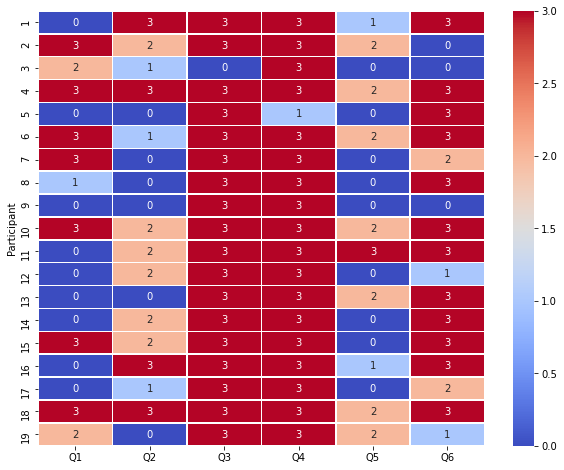

In [13]:
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Aggregating the correct answers for each question across LOQ1, LOQ2, and LOQ3
# For each participant, sum the values across LOQ1, LOQ2, and LOQ3 for each question
heatmap_data = pd.DataFrame()

# Sum the correct answers (1 means correct) for each question
heatmap_data['Q1'] = filtered_data[['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3']].sum(axis=1)
heatmap_data['Q2'] = filtered_data[['Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3']].sum(axis=1)
heatmap_data['Q3'] = filtered_data[['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3']].sum(axis=1)
heatmap_data['Q4'] = filtered_data[['Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3']].sum(axis=1)
heatmap_data['Q5'] = filtered_data[['Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']].sum(axis=1)
heatmap_data['Q6'] = filtered_data[['Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']].sum(axis=1)

# Adding participant identifiers
heatmap_data['Participant'] = filtered_data['Participant']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)


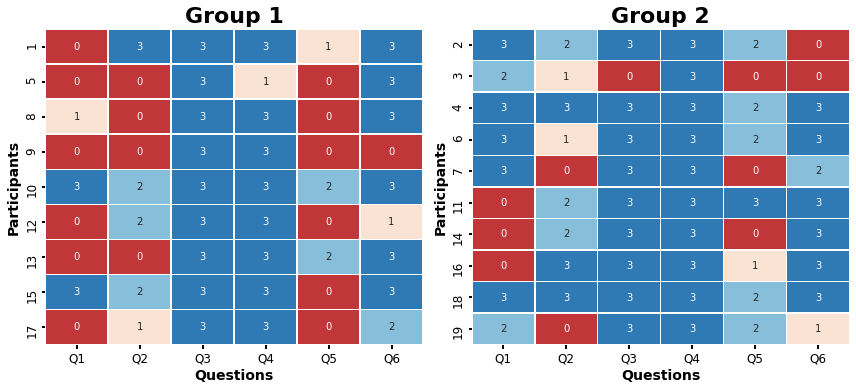

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming filtered_data is already defined and has the necessary columns
heatmap_data = pd.DataFrame()

# Sum the correct answers (1 means correct) for each question
heatmap_data['Q1'] = filtered_data[['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3']].sum(axis=1)
heatmap_data['Q2'] = filtered_data[['Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3']].sum(axis=1)
heatmap_data['Q3'] = filtered_data[['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3']].sum(axis=1)
heatmap_data['Q4'] = filtered_data[['Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3']].sum(axis=1)
heatmap_data['Q5'] = filtered_data[['Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']].sum(axis=1)
heatmap_data['Q6'] = filtered_data[['Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']].sum(axis=1)

# Adding participant identifiers and group
heatmap_data['Participant'] = filtered_data['Participant']
heatmap_data['Group'] = filtered_data['Group']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Create two separate dataframes for each group
group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop('Group', axis=1)
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop('Group', axis=1)

# Inverted color map: making 0 (worst) red, progressing to blue for higher values
cmap = sns.color_palette("RdBu")

# Plotting the heatmaps side by side with specified formatting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # Matching preferred figure size

# Heatmap for Group 1
sns.heatmap(group_1_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax1,
            vmin=0, vmax=group_1_data.values.max())
ax1.set_title('Group 1', fontweight='bold', fontsize=22)
ax1.set_xlabel('Questions', fontweight='bold', fontsize=14)
ax1.set_ylabel('Participants', fontweight='bold', fontsize=14)
ax1.tick_params(axis='x', labelsize=12, width=2)
ax1.tick_params(axis='y', labelsize=12, width=2)

# Heatmap for Group 2
sns.heatmap(group_2_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax2,
            vmin=0, vmax=group_2_data.values.max())
ax2.set_title('Group 2', fontweight='bold', fontsize=22)
ax2.set_xlabel('Questions', fontweight='bold', fontsize=14)
ax2.set_ylabel('Participants', fontweight='bold', fontsize=14)
ax2.tick_params(axis='x', labelsize=12, width=2)
ax2.tick_params(axis='y', labelsize=12, width=2)

# Layout adjustment for consistency
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
file_name = 'NetAnswerHeatmap.png'
plt.savefig(file_name)
plt.show()


In [15]:
import pandas as pd
from scipy.stats import shapiro

# Assuming `filtered_data` is already defined and contains the necessary columns

# Reshape the data to long format (if not already done)
long_format_data = pd.melt(
    filtered_data,
    id_vars=['Participant', 'Group'],
    value_vars=['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3', 'Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3',
                'Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3', 'Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3',
                'Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3', 'Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3'],
    var_name='Question_LOQ',
    value_name='Score'
)

# Extract Question and LOQ columns
long_format_data['Question'] = long_format_data['Question_LOQ'].str.extract('(Q\d)')
long_format_data['LOQ'] = long_format_data['Question_LOQ'].str.extract('(LOQ\d)')
long_format_data.drop('Question_LOQ', axis=1, inplace=True)

# Convert Group and Question to categorical for easier analysis
long_format_data['Group'] = long_format_data['Group'].astype('category')
long_format_data['Question'] = long_format_data['Question'].astype('category')

# List of questions for normality testing
questions = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']

# Perform Shapiro-Wilk test for normality for each question in each group
normality_results = {}

for question in questions:
    for group in [1, 2]:
        # Filter data for the specific question and group
        group_data = long_format_data[(long_format_data['Question'] == question) & (long_format_data['Group'] == group)]['Score']
        
        # Perform Shapiro-Wilk test
        stat, p_value = shapiro(group_data)
        
        # Store the result
        normality_results[(question, group)] = {'Shapiro-Wilk Statistic': stat, 'p-value': p_value}

        # Print the results
        print(f"Normality test for {question} in Group {group}:")
        print(f"  Shapiro-Wilk Statistic = {stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  Result: Data is not normally distributed (reject H0)\n")
        else:
            print("  Result: Data is normally distributed (fail to reject H0)\n")

# The results will help determine if each subset is normally distributed.


Normality test for Q1 in Group 1:
  Shapiro-Wilk Statistic = 0.5487, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

Normality test for Q1 in Group 2:
  Shapiro-Wilk Statistic = 0.6119, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

Normality test for Q2 in Group 1:
  Shapiro-Wilk Statistic = 0.6139, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

Normality test for Q2 in Group 2:
  Shapiro-Wilk Statistic = 0.6318, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

Normality test for Q3 in Group 1:
  Shapiro-Wilk Statistic = 1.0000, p-value = 1.0000
  Result: Data is normally distributed (fail to reject H0)

Normality test for Q3 in Group 2:
  Shapiro-Wilk Statistic = 0.3467, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

Normality test for Q4 in Group 1:
  Shapiro-Wilk Statistic = 0.2938, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)

No

/opt/anaconda3/lib/python3.7/site-packages/scipy/stats/morestats.py:1673: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


In [16]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np

# Assuming `filtered_data` is already defined and contains the necessary columns

# Reshape the data to long format (if not already done)
long_format_data = pd.melt(
    filtered_data,
    id_vars=['Participant', 'Group'],
    value_vars=['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3', 'Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3',
                'Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3', 'Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3',
                'Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3', 'Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3'],
    var_name='Question_LOQ',
    value_name='Score'
)

# Extract Question and LOQ columns
long_format_data['Question'] = long_format_data['Question_LOQ'].str.extract('(Q\d)')
long_format_data.drop('Question_LOQ', axis=1, inplace=True)

# List of questions for the Mann-Whitney U test and variance calculation
questions = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']

# Perform Mann-Whitney U test and calculate variances for each question
results = {}

for question in questions:
    # Filter the data for each question and group
    group_1_scores = long_format_data[(long_format_data['Group'] == 1) & (long_format_data['Question'] == question)]['Score']
    group_2_scores = long_format_data[(long_format_data['Group'] == 2) & (long_format_data['Question'] == question)]['Score']
    
    # Perform Mann-Whitney U test
    u_stat, p_value = mannwhitneyu(group_1_scores, group_2_scores, alternative='two-sided')
    
    # Calculate within-group variances
    variance_group_1 = group_1_scores.var()
    variance_group_2 = group_2_scores.var()
    
    # Calculate variance between the group means for the question
    mean_group_1 = group_1_scores.mean()
    mean_group_2 = group_2_scores.mean()
    variance_between_groups = np.var([mean_group_1, mean_group_2])
    
    # Store the results
    results[question] = {
        'U Statistic': u_stat,
        'p-value': p_value,
        'Variance Group 1': variance_group_1,
        'Variance Group 2': variance_group_2,
        'Variance Between Groups': variance_between_groups
    }

    # Print the results
    print(f"Results for {question}:")
    print(f"  Mann-Whitney U Statistic = {u_stat}, p-value = {p_value}")
    if p_value < 0.05:
        print("  Result: Significant difference between Group 1 and Group 2")
    else:
        print("  Result: No significant difference between Group 1 and Group 2")
    
    print(f"  Variance in Group 1 = {variance_group_1:.4f}")
    print(f"  Variance in Group 2 = {variance_group_2:.4f}")
    print(f"  Variance Between Group Means = {variance_between_groups:.4f}")
    print("\n")


Results for Q1:
  Mann-Whitney U Statistic = 253.5, p-value = 0.005158111692048334
  Result: Significant difference between Group 1 and Group 2
  Variance in Group 1 = 0.1994
  Variance in Group 2 = 0.2402
  Variance Between Group Means = 0.0350


Results for Q2:
  Mann-Whitney U Statistic = 325.5, p-value = 0.1443702560045571
  Result: No significant difference between Group 1 and Group 2
  Variance in Group 1 = 0.2422
  Variance in Group 2 = 0.2540
  Variance Between Group Means = 0.0096


Results for Q3:
  Mann-Whitney U Statistic = 445.5, p-value = 0.09839971684821691
  Result: No significant difference between Group 1 and Group 2
  Variance in Group 1 = 0.0000
  Variance in Group 2 = 0.0931
  Variance Between Group Means = 0.0025


Results for Q4:
  Mann-Whitney U Statistic = 375.0, p-value = 0.139104820487921
  Result: No significant difference between Group 1 and Group 2
  Variance in Group 1 = 0.0712
  Variance in Group 2 = 0.0000
  Variance Between Group Means = 0.0014


Resul

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


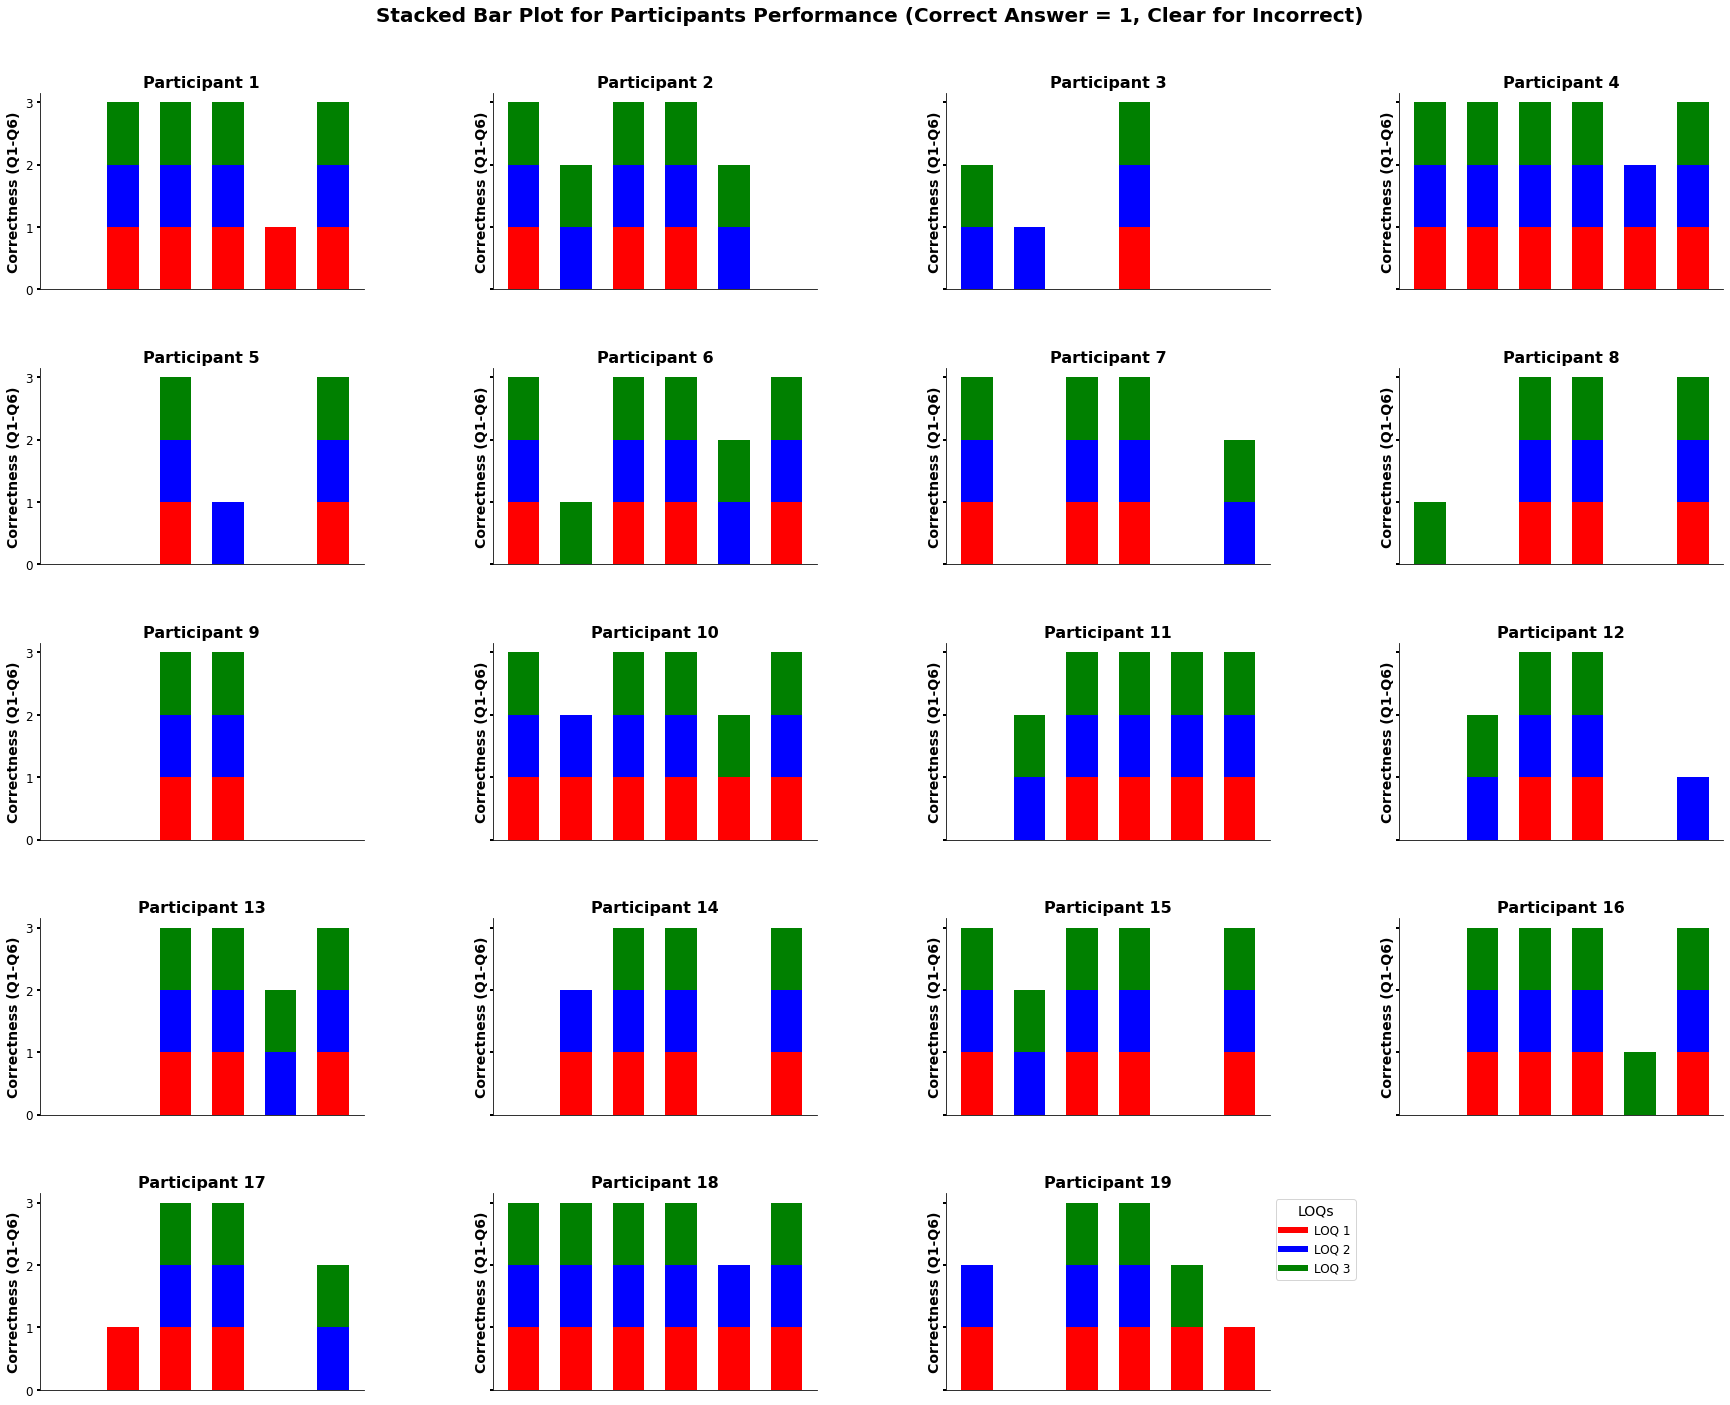

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `data` and `columns_of_interest` are already defined
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Melt the data for easier plotting
melted_data = pd.melt(filtered_data, id_vars=['Participant', 'Group'], var_name='Question_LOQ', value_name='Score')

# Extract the question number and LOQ (time point)
melted_data['Question'] = melted_data['Question_LOQ'].str.extract(r'(Q\d)')
melted_data['LOQ'] = melted_data['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Convert Question to a numeric value for sorting and plotting
melted_data['Question'] = melted_data['Question'].str.replace('Q', '').astype(int)

# Pivot the data to have the LOQs in separate columns for stacking
stacked_data = melted_data.pivot_table(index=['Participant', 'Question'], columns='LOQ', values='Score').fillna(0)

# Plot the stacked bar plot for each participant
def plot_stacked_bars_with_clear(data, **kwargs):
    data = data.reset_index()

    # Define colors for each LOQ: Red for LOQ1, Blue for LOQ2, Green for LOQ3
    loq_colors = {1: 'red', 2: 'blue', 3: 'green'}
    
    # Plot LOQ1, LOQ2, and LOQ3 stacked with clear (transparent) sections where incorrect
    plt.bar(data['Question'], data[1], color=[loq_colors[1] if val > 0 else 'none' for val in data[1]], label='LOQ 1', width=0.6)
    plt.bar(data['Question'], data[2], bottom=data[1], color=[loq_colors[2] if val > 0 else 'none' for val in data[2]], label='LOQ 2', width=0.6)
    plt.bar(data['Question'], data[3], bottom=data[1] + data[2], color=[loq_colors[3] if val > 0 else 'none' for val in data[3]], label='LOQ 3', width=0.6)

# Create a FacetGrid for participants
g = sns.FacetGrid(stacked_data.reset_index(), col="Participant", col_wrap=4, height=4, aspect=1.5)

# Apply the plotting function to each Facet
g.map_dataframe(plot_stacked_bars_with_clear)

# Customize the plot
g.set_titles("Participant {col_name}", size=16, weight='bold')
g.set_axis_labels("Questions", "Correctness Stacked by LOQ")
g.set(xticks=[], xticklabels=[])  # Remove x-axis ticks
g.set(yticks=[0, 1, 2, 3], yticklabels=['0', '1', '2', '3'])

# Customize axis labels separately
for ax in g.axes.flat:
    ax.set_xlabel("")  # No x-axis label
    ax.set_ylabel("Correctness (Q1-Q6)", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=0, width=2)  # Hide x-axis ticks
    ax.tick_params(axis='y', labelsize=12, width=2)

# Adjust the overall layout with more spacing between the plots
plt.subplots_adjust(top=0.92, wspace=0.4, hspace=0.4)
g.fig.suptitle('Stacked Bar Plot for Participants Performance (Correct Answer = 1, Clear for Incorrect)', fontsize=20, weight='bold')

# Add a legend with custom formatting next to the title
handles = [plt.Line2D([0], [0], color='red', lw=6, label='LOQ 1'),
           plt.Line2D([0], [0], color='blue', lw=6, label='LOQ 2'),
           plt.Line2D([0], [0], color='green', lw=6, label='LOQ 3')]
plt.legend(handles=handles, title="LOQs", fontsize=12, title_fontsize=14, frameon=True, 
           loc='upper left', bbox_to_anchor=(1, 1), ncol=1)

file_name = 'BreakDownQ_Answers.png'
plt.savefig(file_name)
plt.show()


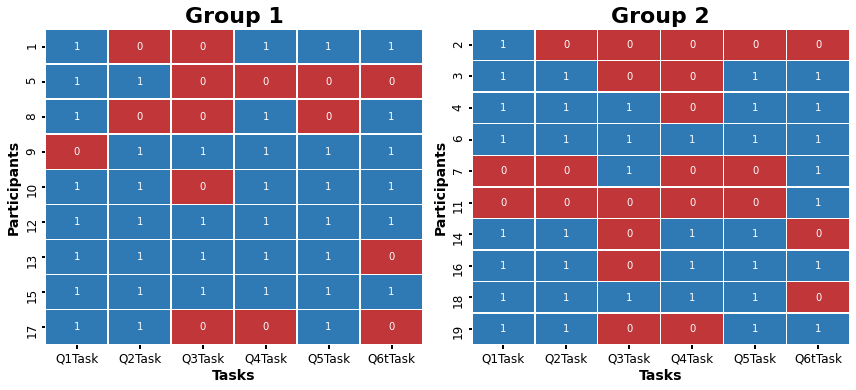

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `data` and `task_columns` are defined and data has the necessary columns
task_columns = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6tTask']

# Ensure that the data has 'Group' and 'Participant' columns
if 'Participant' not in data.columns:
    data['Participant'] = data.index + 1  # Create Participant column if not present

# Filter the necessary columns from the original dataset
filtered_data = data[['Group', 'Participant'] + task_columns]

# Create a new DataFrame to store the task scores
heatmap_data = pd.DataFrame()

# Add task scores for each question (assuming 1 means correct and 0 means incorrect)
for task in task_columns:
    heatmap_data[task] = filtered_data[task]

# Add participant identifiers and group
heatmap_data['Participant'] = filtered_data['Participant']
heatmap_data['Group'] = filtered_data['Group']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Create separate DataFrames for each group
group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop('Group', axis=1)
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop('Group', axis=1)

# Color map: red for low scores progressing to blue for higher scores
cmap = sns.color_palette("RdBu")

# Plotting the heatmaps side by side with updated formatting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap for Group 1
sns.heatmap(group_1_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax1,
            vmin=0, vmax=group_1_data.values.max())
ax1.set_title('Group 1', fontweight='bold', fontsize=22)
ax1.set_xlabel('Tasks', fontweight='bold', fontsize=14)
ax1.set_ylabel('Participants', fontweight='bold', fontsize=14)
ax1.tick_params(axis='x', labelsize=12, width=2)
ax1.tick_params(axis='y', labelsize=12, width=2)

# Heatmap for Group 2
sns.heatmap(group_2_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax2,
            vmin=0, vmax=group_2_data.values.max())
ax2.set_title('Group 2', fontweight='bold', fontsize=22)
ax2.set_xlabel('Tasks', fontweight='bold', fontsize=14)
ax2.set_ylabel('Participants', fontweight='bold', fontsize=14)
ax2.tick_params(axis='x', labelsize=12, width=2)
ax2.tick_params(axis='y', labelsize=12, width=2)

# Layout adjustment for a consistent look
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
file_name = 'TaskPerformanceHeatmap.png'
plt.savefig(file_name)
plt.show()


In [19]:
from scipy.stats import shapiro

# List of task columns
task_columns = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6tTask']

# Run Shapiro-Wilk test for each task in Group 1 and Group 2
print("Shapiro-Wilk Test for Normality:\n")

for task in task_columns:
    # Shapiro-Wilk test for Group 1
    stat_group_1, p_value_group_1 = shapiro(group_1_data[task])
    print(f"{task} - Group 1: Shapiro-Wilk Statistic = {stat_group_1:.4f}, p-value = {p_value_group_1:.4f}")
    if p_value_group_1 < 0.05:
        print("  Result: Data is not normally distributed (reject H0)")
    else:
        print("  Result: Data is normally distributed (fail to reject H0)")
    
    # Shapiro-Wilk test for Group 2
    stat_group_2, p_value_group_2 = shapiro(group_2_data[task])
    print(f"{task} - Group 2: Shapiro-Wilk Statistic = {stat_group_2:.4f}, p-value = {p_value_group_2:.4f}")
    if p_value_group_2 < 0.05:
        print("  Result: Data is not normally distributed (reject H0)")
    else:
        print("  Result: Data is normally distributed (fail to reject H0)")
    
    print("\n")


Shapiro-Wilk Test for Normality:

Q1Task - Group 1: Shapiro-Wilk Statistic = 0.3898, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)
Q1Task - Group 2: Shapiro-Wilk Statistic = 0.5093, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)


Q2Task - Group 1: Shapiro-Wilk Statistic = 0.5358, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)
Q2Task - Group 2: Shapiro-Wilk Statistic = 0.5942, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)


Q3Task - Group 1: Shapiro-Wilk Statistic = 0.6547, p-value = 0.0004
  Result: Data is not normally distributed (reject H0)
Q3Task - Group 2: Shapiro-Wilk Statistic = 0.6405, p-value = 0.0002
  Result: Data is not normally distributed (reject H0)


Q4Task - Group 1: Shapiro-Wilk Statistic = 0.5358, p-value = 0.0000
  Result: Data is not normally distributed (reject H0)
Q4Task - Group 2: Shapiro-Wilk Statistic = 0.6405, p-value = 0.0002
  Result: Data is not normally 

In [20]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

# List of task columns
task_columns = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6tTask']

print("Chi-Square Test (or Fisher's Exact Test) for each task between Group 1 and Group 2:\n")

for task in task_columns:
    # Create a contingency table for Group 1 and Group 2 for the current task
    contingency_table = pd.crosstab(data['Group'], data[task])
    
    # Check the sample sizes to decide between Chi-Square and Fisher's Exact Test
    if contingency_table.values.min() < 5:
        # Use Fisher's Exact Test for small sample sizes
        stat, p_value = fisher_exact(contingency_table)
        test_name = "Fisher's Exact Test"
    else:
        # Use Chi-Square Test for larger samples
        stat, p_value, _, _ = chi2_contingency(contingency_table)
        test_name = "Chi-Square Test"
    
    print(f"{task}: {test_name}")
    print(f"  Test Statistic = {stat:.4f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("  Result: Significant difference between Group 1 and Group 2\n")
    else:
        print("  Result: No significant difference between Group 1 and Group 2\n")


Chi-Square Test (or Fisher's Exact Test) for each task between Group 1 and Group 2:

Q1Task: Fisher's Exact Test
  Test Statistic = 0.5000, p-value = 1.0000
  Result: No significant difference between Group 1 and Group 2

Q2Task: Fisher's Exact Test
  Test Statistic = 0.6667, p-value = 1.0000
  Result: No significant difference between Group 1 and Group 2

Q3Task: Fisher's Exact Test
  Test Statistic = 0.8333, p-value = 1.0000
  Result: No significant difference between Group 1 and Group 2

Q4Task: Fisher's Exact Test
  Test Statistic = 0.1905, p-value = 0.1698
  Result: No significant difference between Group 1 and Group 2

Q5Task: Fisher's Exact Test
  Test Statistic = 0.6667, p-value = 1.0000
  Result: No significant difference between Group 1 and Group 2

Q6tTask: Fisher's Exact Test
  Test Statistic = 1.1667, p-value = 1.0000
  Result: No significant difference between Group 1 and Group 2



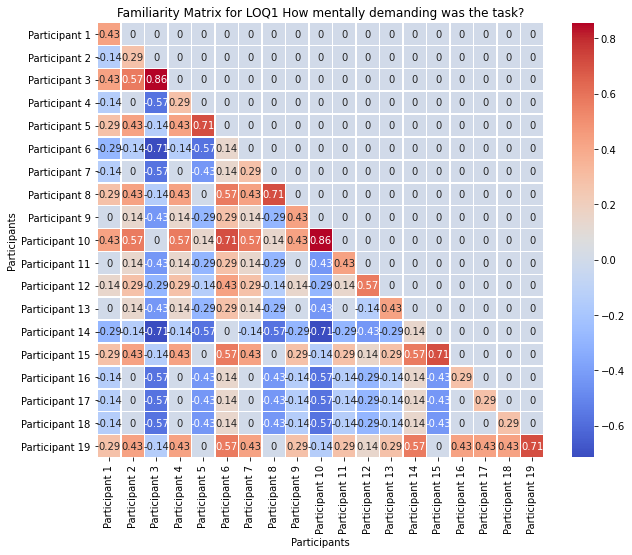

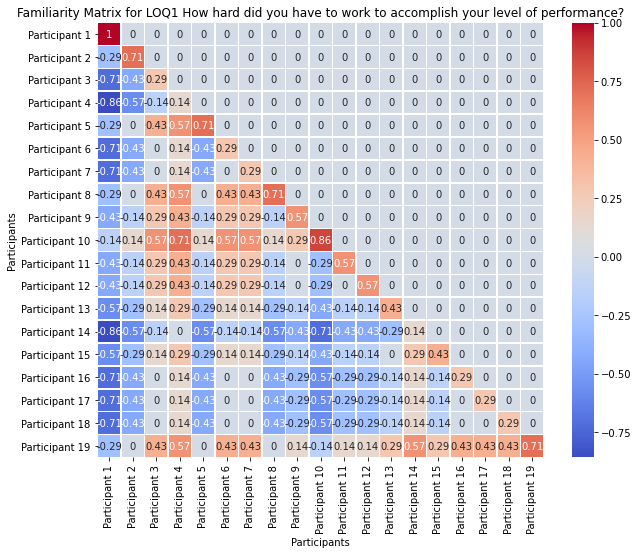

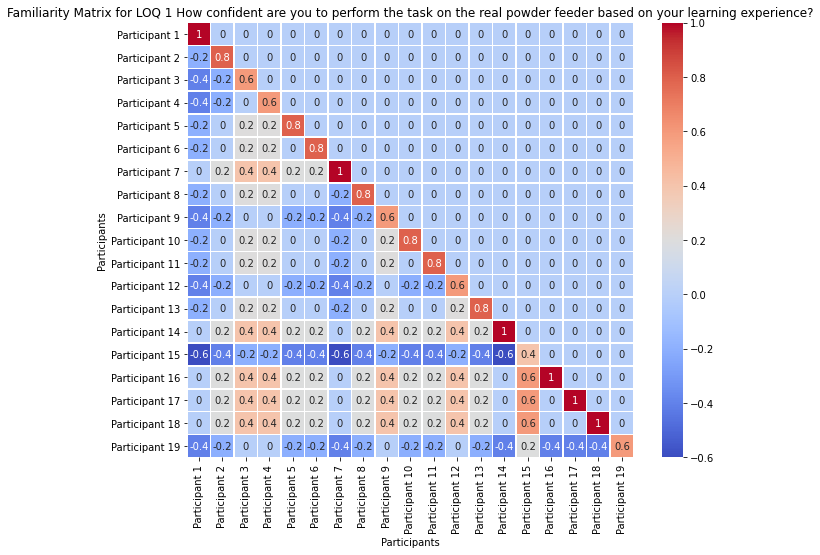

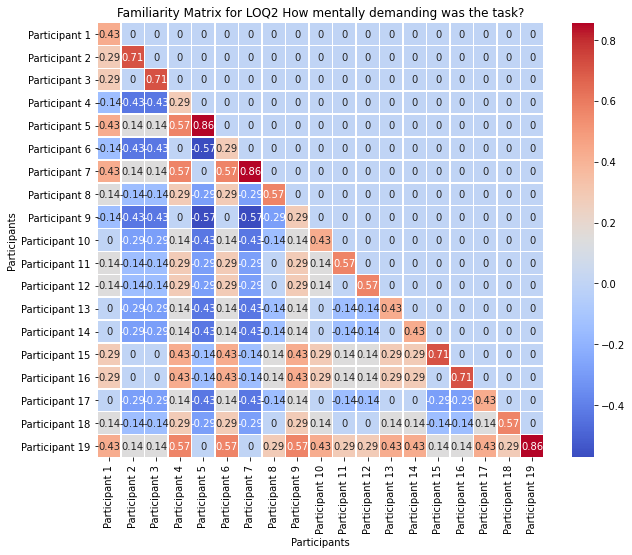

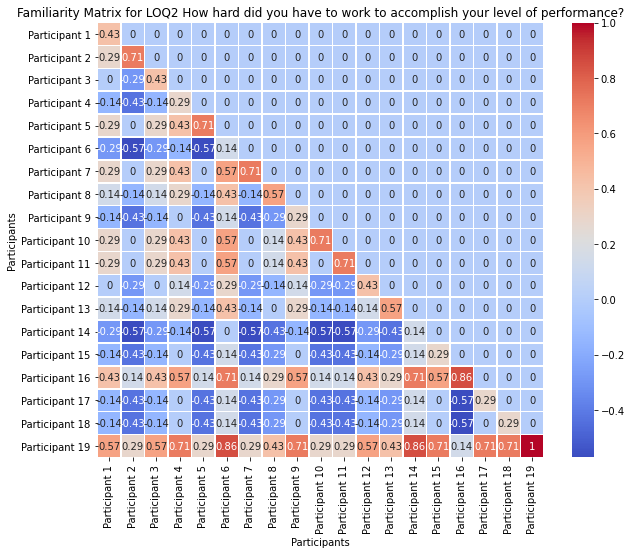

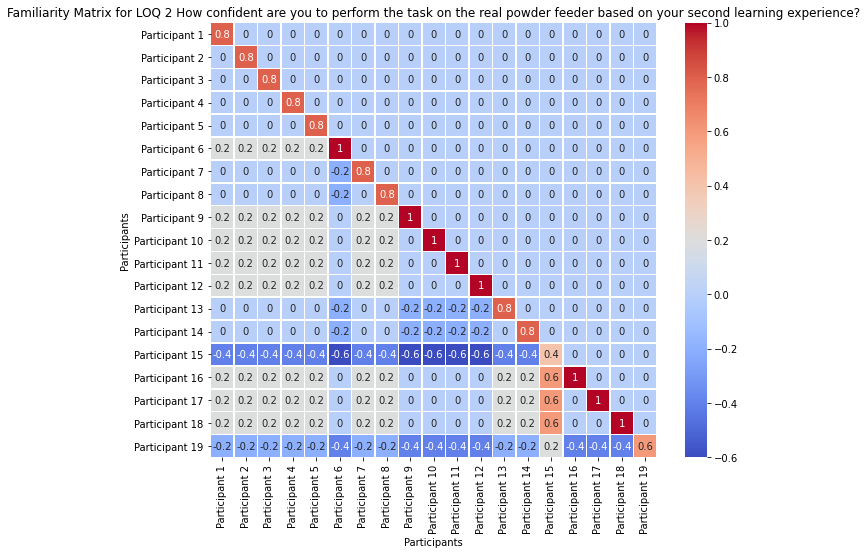

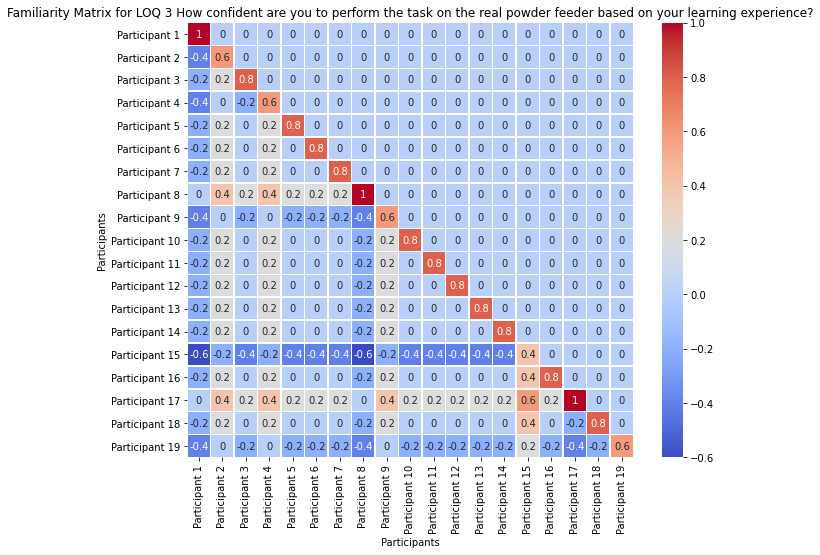

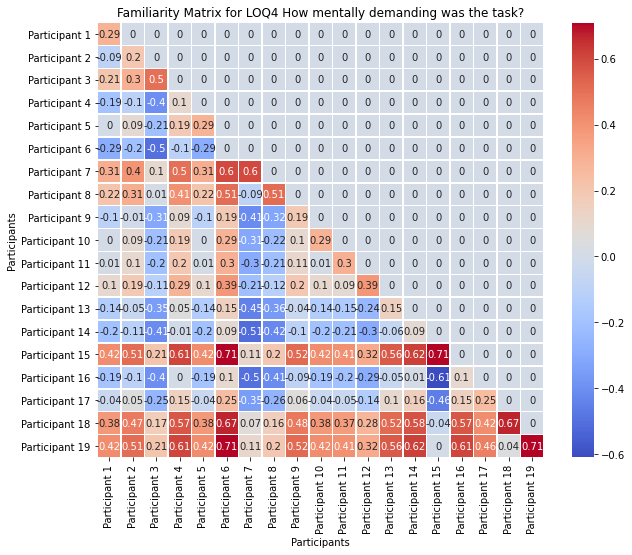

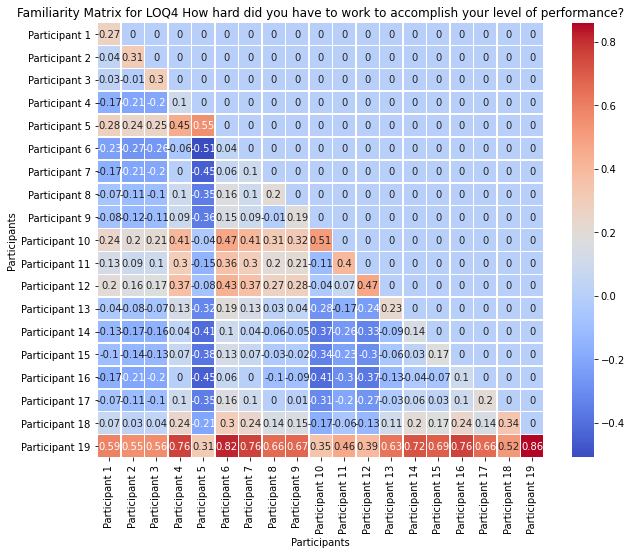

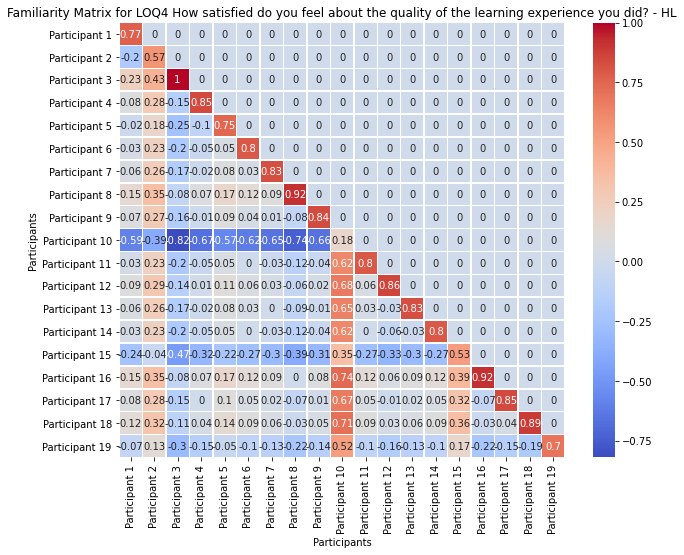

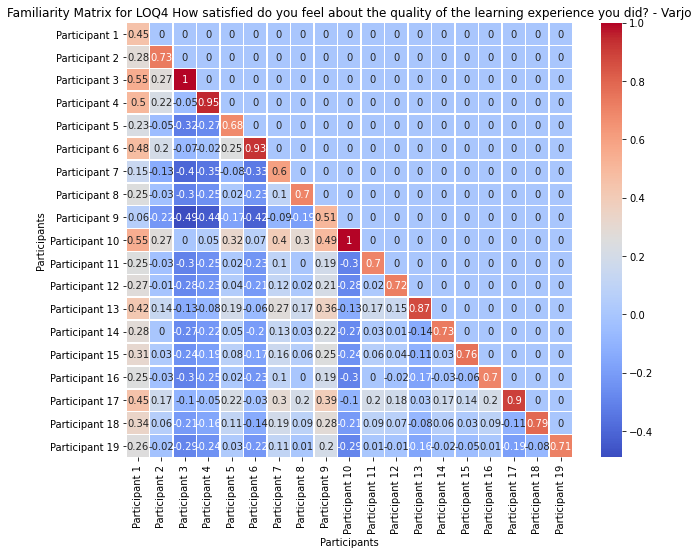

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the original Excel file
file_path = 'workload.xlsx'  # Replace with the actual path
data = pd.read_excel(file_path, sheet_name='Sheet1')


# List of columns for which we want to generate familiarity matrices
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]


# Loop through each relevant column and create a familiarity matrix
for col in relevant_columns:
    # Extract the participant scores for the current column
    participant_scores = data[col].values

    # Initialize the familiarity matrix (zeroes initially)
    num_participants = len(participant_scores)
    familiarity_matrix = np.zeros((num_participants, num_participants))

    # Fill in the diagonal and below diagonal with differences (non-absolute)
    for i in range(num_participants):
        for j in range(i + 1):
            if i == j:
                familiarity_matrix[i, j] = participant_scores[i]  # Diagonal: participant's own score
            else:
                familiarity_matrix[i, j] = participant_scores[i] - participant_scores[j]  # Difference between participants

    # Convert matrix to a DataFrame for better visualization
    familiarity_matrix_df = pd.DataFrame(familiarity_matrix, 
                                         columns=[f'Participant {i+1}' for i in range(num_participants)],
                                         index=[f'Participant {i+1}' for i in range(num_participants)])

    # Create a heatmap for the familiarity matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(familiarity_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)
    plt.title(f'Familiarity Matrix for {col}')
    plt.xlabel('Participants')
    plt.ylabel('Participants')
    plt.show()


In [22]:
import pandas as pd
import numpy as np

# Load the data
file_path = 'workload.xlsx'  # Replace with the actual path to your file
data = pd.read_excel(file_path, sheet_name='Sheet1')

# Define the relevant columns
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]

# Add participant numbers based on the DataFrame index
data['Participant'] = data.index + 1  # Adjusting to start Participant numbers from 1

# Split data by group
group_1_data = data[data['Group'] == 1][['Participant'] + relevant_columns]
group_2_data = data[data['Group'] == 2][['Participant'] + relevant_columns]

# Display participants in each group
print("Participants in Group 1:")
print(group_1_data['Participant'].tolist())

print("\nParticipants in Group 2:")
print(group_2_data['Participant'].tolist())

# Calculate summary statistics for Group 1 and Group 2
group_1_stats = group_1_data[relevant_columns].describe().T
group_2_stats = group_2_data[relevant_columns].describe().T

# Display summary statistics
print("\nGroup 1 Summary Statistics:")
print(group_1_stats[['mean', 'std']])

print("\nGroup 2 Summary Statistics:")
print(group_2_stats[['mean', 'std']])


Participants in Group 1:
[1, 5, 8, 9, 10, 12, 13, 15, 17]

Participants in Group 2:
[2, 3, 4, 6, 7, 11, 14, 16, 18, 19]

Group 1 Summary Statistics:
                                                        mean       std
LOQ1 How mentally demanding was the task?           0.571429  0.188982
LOQ1 How hard did you have to work to accomplis...  0.619048  0.225877
LOQ 1 How confident are you to perform the task...  0.755556  0.194365
LOQ2 How mentally demanding was the task?           0.523810  0.174964
LOQ2 How hard did you have to work to accomplis...  0.476190  0.174964
LOQ 2 How confident are you to perform the task...  0.844444  0.194365
LOQ 3 How confident are you to perform the task...  0.800000  0.200000
LOQ4 How mentally demanding was the task?           0.341111  0.174101
LOQ4 How hard did you have to work to accomplis...  0.310000  0.153867
LOQ4 How satisfied do you feel about the qualit...  0.725556  0.232869
LOQ4 How satisfied do you feel about the qualit...  0.732222  0.177678

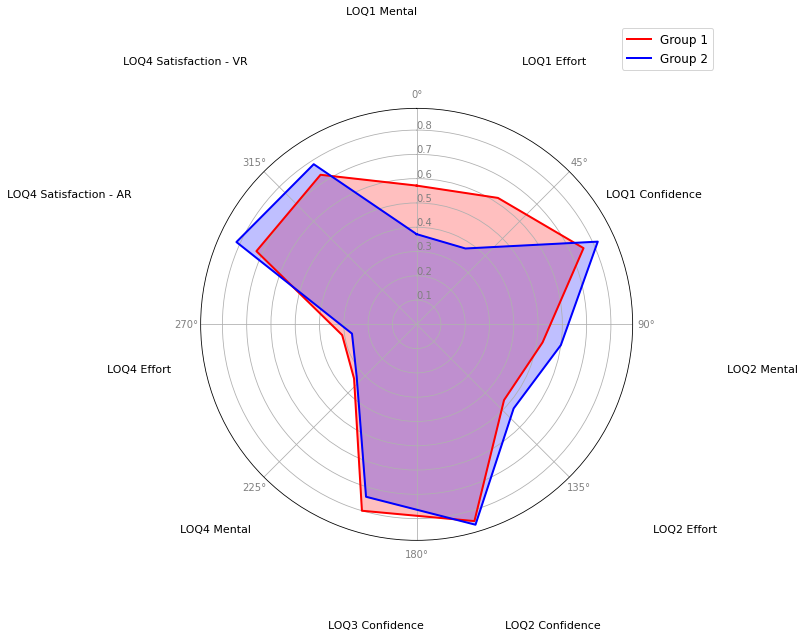

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Updated labels to match the 'relevant_columns'
labels_short = [
    'LOQ1 Mental', 'LOQ1 Effort', 'LOQ1 Confidence',
    'LOQ2 Mental', 'LOQ2 Effort', 'LOQ2 Confidence',
    'LOQ3 Confidence',
    'LOQ4 Mental', 'LOQ4 Effort', 'LOQ4 Satisfaction - AR',
    'LOQ4 Satisfaction - VR'
]

# Function to create radar chart for group averages
def create_radar_chart(groups_mean, labels, group_names):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Initialize the radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))  # Larger figure size

    # Define colors for each group
    colors = ['red', 'blue']

    # Plot data for each group
    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, color=colors[i], label=group_names[i])
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    # Adjust the label positions and spacing
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Adjust the label positions to avoid overlap with the plot
    label_padding = ax.get_rmax() + 0.4  # Increase padding for the labels
    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(
            angle_rad, label_padding, label, size=11, horizontalalignment=ha, verticalalignment='center'
        )

    # Increase space around the chart for labels
    plt.subplots_adjust(left=0.2, right=0.8, top=0.85, bottom=0.15)

    # Customize radial labels
    ax.set_rlabel_position(0)
    ax.tick_params(colors='grey', labelsize=10)  # Customize radial ticks
    for label in ax.get_yticklabels():
        label.set_color('grey')

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), fontsize=12)

    # Save and show the plot
    file_name = 'Updated_Radar.png'
    plt.savefig(file_name)
    plt.show()

# Calculate average profile for Group 1 and Group 2 based on the relevant columns
group_1_mean = data[data['Group'] == 1][relevant_columns].mean()
group_2_mean = data[data['Group'] == 2][relevant_columns].mean()

# Plot radar chart with group averages and updated labels
create_radar_chart([group_1_mean, group_2_mean], labels_short, ['Group 1', 'Group 2'])


FileNotFoundError: [Errno 2] No such file or directory: 'your_dataset.csv'

import numpy as np
import matplotlib.pyplot as plt

# Updated labels to match 'relevant_columns'
labels_short = [
    'LOQ1\nMental \n Workload', 'LOQ1\nEffort Learning', 'LOQ1\nConfidence',
    'LOQ2\nMental \n Workload', 'LOQ2\nEffort Learning', 'LOQ2\nConfidence',
    'LOQ3\nConfidence',
    'LOQ4\nMental \n Workload', 'LOQ4\nTask Effort', 'LOQ4\nSatisfaction - AR',
    'LOQ4\nSatisfaction - VR'
]

# Function to create a radar chart for a single participant
def create_radar_chart_single(ax, participant_data, labels, participant_id, color):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Plot data for the participant
    values = participant_data.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, linewidth=2, color=color)
    ax.fill(angles, values, color=color, alpha=0.1)

    # Customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Remove degree ticks
    ax.set_xticks([])

    # Set a consistent distance for all labels
    label_distance = ax.get_rmax() + 0.35  # Uniform distance for labels

    # Add labels with uniform distance and slight rotation for even distribution
    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(angle_rad, label_distance, label, size=8, fontweight='bold', 
                horizontalalignment=ha, verticalalignment='center')

    # Set participant title above the plot with additional padding
    ax.text(0.7, 1.3, f'Participant {participant_id}', size=10, fontweight='bold', 
            color=color, ha='center', va='center', transform=ax.transAxes)

# Plotting all participants in a 4x5 grid for better spacing
num_participants = len(data)
fig, axes = plt.subplots(5, 4, figsize=(26, 24), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart Comparison for All Participants', size=20, fontweight='bold', y=1.08)

# Flatten axes for easier iteration
axes = axes.flatten()

# Loop through each participant and plot
for idx, (participant_id, participant_data) in enumerate(data[relevant_columns].iterrows()):
    if idx < len(axes):  # Ensure we don't exceed available subplots
        ax = axes[idx]
        # Set color based on group
        color = 'red' if data.loc[participant_id, 'Group'] == 1 else 'blue'
        # Create the radar chart for this participant
        create_radar_chart_single(ax, participant_data, labels_short, participant_id + 1, color)

# Hide any remaining empty subplots
for i in range(num_participants, len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.7, wspace=0.4)  # Adjust spacing between subplots
plt.show()


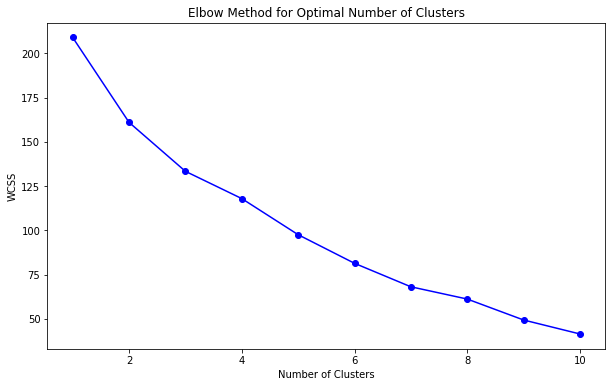

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load your data (assuming it's already in a DataFrame called `data`)
# and select the relevant columns
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]

# Extract the relevant columns and scale the data
X = data[relevant_columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# List to store the WCSS values for each number of clusters
wcss = []

# Calculate WCSS for cluster counts from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # WCSS is stored in `inertia_`

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


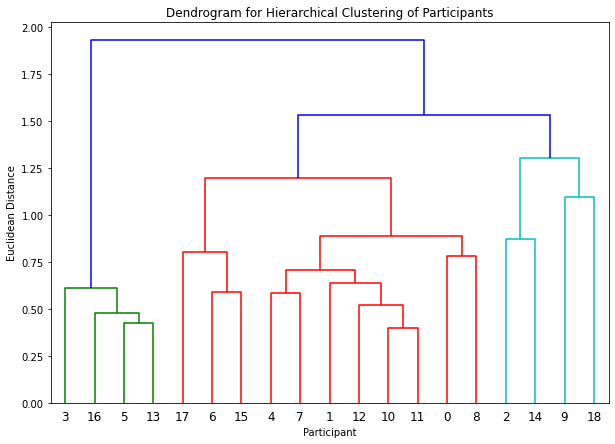

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
import numpy as np

# Load data and select relevant columns
file_path = 'workload.xlsx'  # Replace with the actual file path
data = pd.read_excel(file_path, sheet_name='Sheet1')
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]

# Generate Dendrogram
plt.figure(figsize=(10, 7))
plt.title("Dendrogram for Hierarchical Clustering of Participants")
dendrogram = sch.dendrogram(sch.linkage(data[relevant_columns], method='ward'))
plt.xlabel('Participant')
plt.ylabel('Euclidean Distance')
plt.show()


In [14]:
# Apply KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
data['Cluster'] = kmeans.fit_predict(data[relevant_columns])

# Add a column for participant numbers (if not present)
data['Participant'] = data.index + 1

# Get the cluster average profiles
cluster_means = data.groupby('Cluster')[relevant_columns].mean()

# Display participant numbers in each cluster
clustered_participants = data.groupby('Cluster')['Participant'].apply(list).reset_index()
clustered_participants.columns = ['Cluster', 'Participants']
print("Participants in each cluster:\n", clustered_participants)


Participants in each cluster:
    Cluster                            Participants
0        0  [1, 2, 3, 5, 7, 8, 10, 11, 12, 15, 19]
1        1           [4, 6, 9, 13, 14, 16, 17, 18]


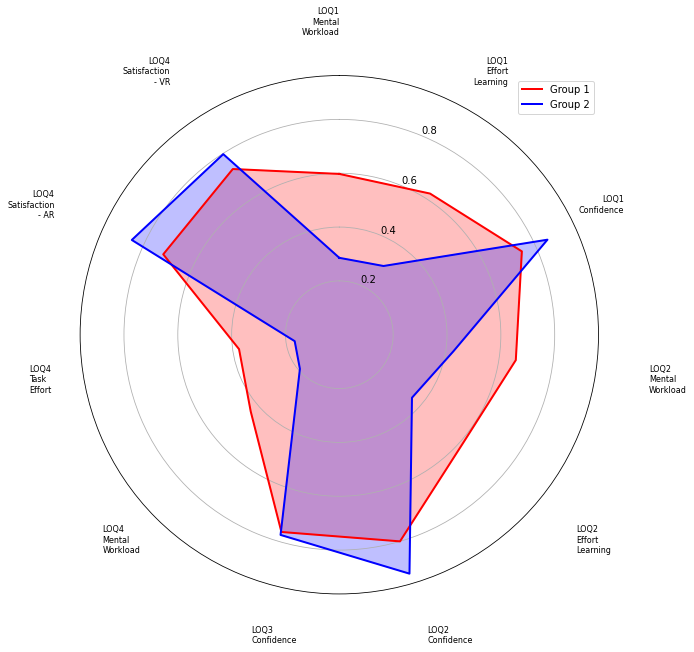

In [31]:
# Define labels for radar chart
labels_short = [
    'LOQ1\nMental\nWorkload', 'LOQ1\nEffort\nLearning', 'LOQ1\nConfidence',
    'LOQ2\nMental\nWorkload', 'LOQ2\nEffort\nLearning', 'LOQ2\nConfidence',
    'LOQ3\nConfidence', 'LOQ4\nMental\nWorkload', 'LOQ4\nTask\nEffort',
    'LOQ4\nSatisfaction\n- AR', 'LOQ4\nSatisfaction\n- VR'
]

# Function to create radar chart for clusters
def create_radar_chart(groups_mean, labels, group_names):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(12, 16), subplot_kw=dict(polar=True))
    colors = ['red', 'blue']

    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, color=colors[i], label=group_names[i])
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks([])

    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(angle_rad, ax.get_rmax() + 0.2, label, size=8, ha=ha, va='center')

    plt.subplots_adjust(left=0.2, right=0.8, top=0.9, bottom=0.1)
    plt.legend(loc='upper right',bbox_to_anchor=(1, 1), ncol=1)
    file_name = 'UP_Updated_Radar.png'
    plt.savefig(file_name)
    plt.show()

# Generate radar chart with average profiles for each cluster
create_radar_chart(cluster_means.values, labels_short, ['Group 1', 'Group 2'])


In [38]:
# Calculate statistics for each cluster
cluster_summary = data.groupby('Cluster')[relevant_columns].mean()

# Calculate the group proportions within each cluster
group_proportions = data.groupby('Cluster')['Group'].value_counts(normalize=True).unstack().fillna(0)
cluster_summary_with_groups = pd.concat([cluster_summary, group_proportions], axis=1)

print("Cluster Summary with Average Values and Group Proportions:\n")
print(cluster_summary_with_groups)

# Display participants per cluster
print("\nParticipants in each cluster:\n", clustered_participants)


Cluster Summary with Average Values and Group Proportions:

         LOQ1 How mentally demanding was the task?  \
Cluster                                              
0                                         0.597403   
1                                         0.285714   

         LOQ1 How hard did you have to work to accomplish your level of performance?  \
Cluster                                                                                
0                                                 0.623377                             
1                                                 0.303571                             

         LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?  \
Cluster                                                                                                                 
0                                                 0.745455                                                              
1      

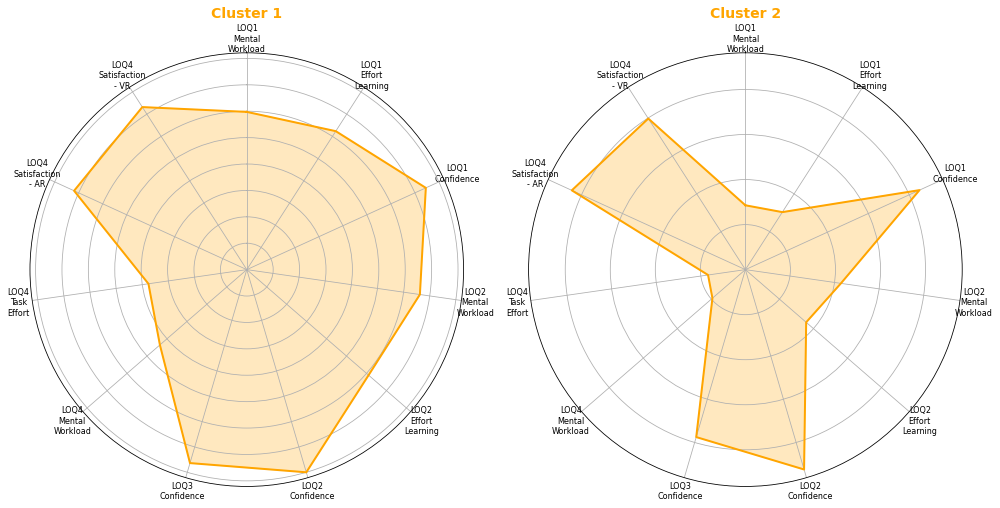

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Load data and select relevant columns
file_path = 'workload.xlsx'  # Replace with the actual file path
data = pd.read_excel(file_path, sheet_name='Sheet1')
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]

# Apply KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
data['Cluster'] = kmeans.fit_predict(data[relevant_columns])

# Calculate average profile for each cluster
cluster_means = data.groupby('Cluster')[relevant_columns].mean()

# Define labels for radar chart
labels_short = [
    'LOQ1\nMental\nWorkload', 'LOQ1\nEffort\nLearning', 'LOQ1\nConfidence',
    'LOQ2\nMental\nWorkload', 'LOQ2\nEffort\nLearning', 'LOQ2\nConfidence',
    'LOQ3\nConfidence', 'LOQ4\nMental\nWorkload', 'LOQ4\nTask\nEffort',
    'LOQ4\nSatisfaction\n- AR', 'LOQ4\nSatisfaction\n- VR'
]

# Function to create a radar chart for a single cluster
def create_radar_chart(ax, cluster_mean, labels, cluster_name, color):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    values = cluster_mean.tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2, label=cluster_name)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels([])

    # Set title for each subplot
    ax.set_title(cluster_name, color=color, fontsize=14, fontweight='bold')

# Create side-by-side radar charts for each cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True))
colors = ['orange', 'orange']

# Plot for Cluster 0
create_radar_chart(ax1, cluster_means.iloc[0], labels_short, 'Cluster 1', colors[0])

# Plot for Cluster 1
create_radar_chart(ax2, cluster_means.iloc[1], labels_short, 'Cluster 2', colors[1])

# Adjust layout and show plot
plt.tight_layout()
file_name = 'Up_Updated_Radar_Sep.png'
plt.savefig(file_name)
plt.show()


In [ ]:
# Apply KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
data['Cluster'] = kmeans.fit_predict(data[relevant_columns])

# Add a column for participant numbers (if not present)
data['Participant'] = data.index + 1

# Get the cluster average profiles
cluster_means = data.groupby('Cluster')[relevant_columns].mean()

# Display participant numbers in each cluster
clustered_participants = data.groupby('Cluster')['Participant'].apply(list).reset_index()
clustered_participants.columns = ['Cluster', 'Participants']
print("Participants in each cluster:\n", clustered_participants)


In [ ]:
# Define labels for radar chart
labels_short = [
    'LOQ1\nMental\nWorkload', 'LOQ1\nEffort\nLearning', 'LOQ1\nConfidence',
    'LOQ2\nMental\nWorkload', 'LOQ2\nEffort\nLearning', 'LOQ2\nConfidence',
    'LOQ3\nConfidence', 'LOQ4\nMental\nWorkload', 'LOQ4\nTask\nEffort',
    'LOQ4\nSatisfaction\n- HL', 'LOQ4\nSatisfaction\n- VR'
]

# Function to create radar chart for clusters
def create_radar_chart(groups_mean, labels, group_names):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    colors = ['red', 'blue']

    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, color=colors[i], label=group_names[i])
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks([])

    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(angle_rad, ax.get_rmax() + 0.1, label, size=8, fontweight='bold', ha=ha, va='center')

    plt.subplots_adjust(left=0.2, right=0.8, top=0.9, bottom=0.1)
    plt.legend(loc='upper right')
    plt.show()

# Generate radar chart with average profiles for each cluster
create_radar_chart(cluster_means.values, labels_short, ['Cluster 0', 'Cluster 1'])


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# Assuming `data` is already loaded and `relevant_columns` are defined
# Run KMeans clustering with the optimal number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=2, random_state=0)
data['Cluster'] = kmeans.fit_predict(data[relevant_columns])

# Add a column to store participant IDs (optional, if index isn't already participant number)
data['Participant'] = data.index + 1  # Adjust if participants start at 1

# Group by cluster and list participants in each cluster
clustered_participants = data.groupby('Cluster')['Participant'].apply(list).reset_index()
clustered_participants.columns = ['Cluster', 'Participants']

# Display participants in each cluster
print(clustered_participants)

# Optional: To see more detailed summary of each cluster
cluster_summary = data.groupby('Cluster')[relevant_columns + ['Group']].mean()
print("\nCluster Summary with Group and Participant Numbers:\n", cluster_summary)


In [ ]:
print(filtered_data.columns)

In [ ]:
import pandas as pd

# Define the data
data = pd.DataFrame({
    'Group': [1]*9 + [2]*10,
    'Participant': [1, 5, 8, 9, 10, 12, 13, 15, 17, 2, 3, 4, 6, 7, 11, 14, 16, 18, 19],
    'Q1Task': [1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1],
    'Q2Task': [1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    'Q3Task': [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1],
    'Q4Task': [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0],
    'Q5Task': [1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1],
    'Q6Task': [1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1]
})

# Define task types
procedural_tasks = ['Q1Task', 'Q4Task', 'Q6Task']
spatial_tasks = ['Q2Task', 'Q3Task', 'Q5Task']

# Calculate the number of participants who made a mistake (error = 1) for each task type
procedural_mistakes = data[procedural_tasks].sum(axis=0)
spatial_mistakes = data[spatial_tasks].sum(axis=0)

# Calculate the average number of participants who made a mistake for each type of task
average_procedural_mistakes = procedural_mistakes.mean()
average_spatial_mistakes = spatial_mistakes.mean()

print(f"Average number of participants who made mistakes in procedural tasks: {average_procedural_mistakes}")
print(f"Average number of participants who made mistakes in spatial tasks: {average_spatial_mistakes}")
